```
---
title: Black list of small molecules in BioPAX
tags: BioPAX, smallMolecules, SPARQL, Reactome, ChEBI, blacklist, yeast, Saccharomyces_cerevisiae
lang: en
version: 0.8
date: 2026-07-10
---
```

In [1]:
#import importlib
import IPython
#import json
import matplotlib.pyplot as plt
#import networkx as nx
#import os
import pandas
#import rdflib
#import rdflib.namespace
import scipy.stats as stats
import sparqldataframe
from SPARQLWrapper import SPARQLWrapper, JSON
#import sys

In [2]:
reactomeVersion = 96 # 2026-03-25
#chebiVersion = 252 # CHECKED BY QUERY BELOW
#endpointURL = "http://localhost:3030/reactome/query"
#endpointURL = "http://localhost:3030/chebi/query"
endpointURL = "http://localhost:3030/reactomeChEBI/query"
rdfFormat = "turtle"

In [3]:
prefixes = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

PREFIX CHEBI: <http://purl.obolibrary.org/obo/CHEBI_>
PREFIX chebirel: <http://purl.obolibrary.org/obo/CHEBI#>
PREFIX oboInOwl: <http://www.geneontology.org/formats/oboInOwl#>

PREFIX bp3: <http://www.biopax.org/release/biopax-level3.owl#>

PREFIX reactome: <http://www.reactome.org/biopax/{}/48887#>
""".format(reactomeVersion)

In [4]:
query="""
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

SELECT ?ontology ?versionIRI (REPLACE(REPLACE(STR(?versionIRI), 'http://purl.obolibrary.org/obo/chebi/', ''), '/chebi.owl', '') AS ?versionNumber)
WHERE {
  ?ontology rdf:type owl:Ontology .
  ?ontology owl:versionIRI ?versionIRI .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

chebiVersion = int(results["results"]["bindings"][0]["versionNumber"]["value"])
print("ChEBI version: {}".format(chebiVersion))

ChEBI version: 252


In [5]:
def displaySparqlResults(results):
    '''
    Displays as HTML the result of a SPARQLWrapper query in a Jupyter notebook.
    
        Parameters:
            results (dictionnary): the result of a call to SPARQLWrapper.query().convert()
    '''
    variableNames = results['head']['vars']
    tableCode = '<table><tr><th>{}</th></tr><tr>{}</tr></table>'.format('</th><th>'.join(variableNames), '</tr><tr>'.join('<td>{}</td>'.format('</td><td>'.join([row[vName]['value'] if vName in row.keys() else "&nbsp;" for vName in variableNames]))for row in results["results"]["bindings"]))
    IPython.display.display(IPython.display.HTML(tableCode))

# 1. General metrics

## 1.1 Reactions

In [6]:
query = """
SELECT ?reactionType (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction rdf:type ?reactionType .
}
GROUP BY ?reactionType
ORDER BY DESC(?nbReactions)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

reactionType,nbReactions
http://www.biopax.org/release/biopax-level3.owl#BiochemicalReaction,1642


## 1.2 Small molecules and mapping to ChEBI

In [7]:
query = """
SELECT ?moleculeType (COUNT(DISTINCT ?molecule) AS ?nbMolecules)
WHERE {
  ?molecule rdf:type/(rdfs:subClassOf*) bp3:SmallMolecule .
  ?molecule rdf:type ?moleculeType .
}
GROUP BY ?moleculeType
ORDER BY DESC(?nbMolecules)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

moleculeType,nbMolecules
http://www.biopax.org/release/biopax-level3.owl#SmallMolecule,1568


In [8]:
query = """
SELECT (COUNT(DISTINCT ?chebiID) AS ?nbMoleculesChEBI)
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

nbMoleculesChEBI
787


In [9]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
  
  # ChEBI URL -> ident
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) 
  #
  # ChEBI ident -> URL
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) 
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
}
"""

df = sparqldataframe.query(endpointURL, prefixes+query)
print("Nb ChEBI identifiers with label: {}".format(len(df)))
print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))
df.to_csv("results/reactome_version{}_sce_chebiMolecules.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb ChEBI identifiers with label: 787
Nb distinct ChEBI identifiers: 787


# 2. Distribution nb reactions by molecule

In [10]:
query = """
SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction (bp3:left|bp3:right) ?molecule .

  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
}
GROUP BY ?chebiID ?moleculeChebiLabel
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')

print("Nb molecules ChEBI molecules associated to >= 1 reaction: {}".format(len(set(df['chebiID']))))

Nb molecules ChEBI molecules associated to >= 1 reaction: 671


<div class="alert alert-block alert-warning">
<b>787 - 671 = 116</b> Reactome molecules are neither consumed nor produced by some chemical reactions, even as components of complexes.
</div>

In [11]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel ?nbReactions
WHERE {
  {
    SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
    WHERE {
      ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
      ?reaction (bp3:left|bp3:right) ?molecule .

      ?molecule rdf:type bp3:SmallMolecule .
      ?molecule bp3:entityReference/bp3:xref [
        rdf:type bp3:UnificationXref ;
        bp3:db "ChEBI" ;
        bp3:id ?chebiID
      ] .
      #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
      BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
      ?moleculeChebi rdfs:label ?moleculeChebiLabel .
    }
    GROUP BY ?chebiID ?moleculeChebiLabel
  }
  UNION
  {
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?molecule rdf:type bp3:SmallMolecule .
        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    MINUS
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
        ?reaction (bp3:left|bp3:right) ?molecule .

        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    
    #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
    BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
    ?moleculeChebi rdfs:label ?moleculeChebiLabel .
    BIND(0 AS ?nbReactions)
  }
}
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbReactions', ascending = False)

print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))

df.to_csv("results/reactome_version{}_sce_chebiMoleculesNbReactions.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct ChEBI identifiers: 787


In [12]:
df.head()

,chebiID,moleculeChebiLabel,nbReactions
0,CHEBI:15377,water,303
1,CHEBI:30616,ATP(4-),288
2,CHEBI:15378,hydron,283
3,CHEBI:456216,ADP(3-),258
4,CHEBI:43474,hydrogenphosphate,173


In [13]:
df[df['nbReactions'] == 0]

,chebiID,moleculeChebiLabel,nbReactions
746,CHEBI:47923,tripeptide,0
747,CHEBI:49883,tetra-mu3-sulfido-tetrairon,0
748,CHEBI:50746,N(6)-dihydrolipoyl-L-lysine residue,0
749,CHEBI:533015,"3,3',5-triiodo-L-thyronine zwitterion",0
751,CHEBI:57595,L-histidine zwitterion,0
...,...,...,...
705,CHEBI:17490,O-palmitoyl-L-carnitine,0
704,CHEBI:17256,2'-deoxyadenosine,0
703,CHEBI:17240,itaconate(2-),0
702,CHEBI:17172,2'-deoxyguanosine,0


# 3. Distribution nb of molecules by (master) reaction

In [14]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .

  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))


Nb distinct reactions: 1154


<div class="alert alert-block alert-warning">
<b>1,642 - 1,154 = 488</b> Reactome reactions neither consume nor produce some molecules.
</div>

In [15]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .

  OPTIONAL {
  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  }
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbMolecules', ascending = False)

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))

df.to_csv("results/reactome_version{}_sce_chebiReactionsNbMolecules.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions: 1642


In [16]:
df[df['nbMolecules'] == 0]

,reaction,nbMolecules
1478,http://www.reactome.org/biopax/96/68322#Bioche...,0
1462,http://www.reactome.org/biopax/96/68322#Bioche...,0
1479,http://www.reactome.org/biopax/96/68322#Bioche...,0
1480,http://www.reactome.org/biopax/96/68322#Bioche...,0
1482,http://www.reactome.org/biopax/96/68322#Bioche...,0
...,...,...
1312,http://www.reactome.org/biopax/96/68322#Bioche...,0
1311,http://www.reactome.org/biopax/96/68322#Bioche...,0
1310,http://www.reactome.org/biopax/96/68322#Bioche...,0
1309,http://www.reactome.org/biopax/96/68322#Bioche...,0


# 4. Load data

In [17]:
dfMolecules = pandas.read_csv("results/reactome_version{}_sce_chebiMoleculesNbReactions.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactions = pandas.read_csv("results/reactome_version{}_sce_chebiReactionsNbMolecules.tsv.gz".format(reactomeVersion), sep="\t")

In [18]:
res = []
for i, row in dfMolecules.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMolecules['molecule'] = res

In [19]:
dfMolecules.head(30)

,chebiID,moleculeChebiLabel,nbReactions,molecule
0,CHEBI:15377,water,303,water CHEBI:15377
1,CHEBI:30616,ATP(4-),288,ATP(4-) CHEBI:30616
2,CHEBI:15378,hydron,283,hydron CHEBI:15378
3,CHEBI:456216,ADP(3-),258,ADP(3-) CHEBI:456216
4,CHEBI:43474,hydrogenphosphate,173,hydrogenphosphate CHEBI:43474
5,CHEBI:57287,coenzyme A(4-),72,coenzyme A(4-) CHEBI:57287
6,CHEBI:57783,NADPH(4-),72,NADPH(4-) CHEBI:57783
7,CHEBI:58349,NADP(3-),72,NADP(3-) CHEBI:58349
8,CHEBI:33019,diphosphate(3-),67,diphosphate(3-) CHEBI:33019
9,CHEBI:29985,L-glutamate(1-),45,L-glutamate(1-) CHEBI:29985


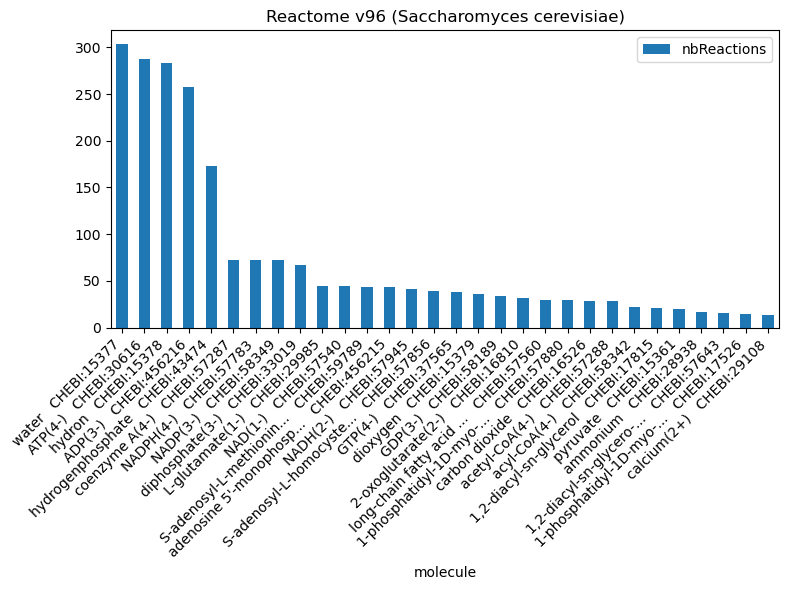

In [20]:
ax = dfMolecules.head(30).plot.bar(x="molecule", y="nbReactions", title="Reactome v{} (Saccharomyces cerevisiae)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_sce_chebiMoleculesNbReactions.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

# 5. Molecule participation over-representation

## 5.1 Metrics computation

In [21]:
query = """
SELECT DISTINCT ?reactionFromIdent ?chebiID
WHERE {
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .
 
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct reactions to produced molecules: {}".format(len(df)))
print("Nb distinct reactions producing >= 1 molecule: {}".format(len(df['reactionFromIdent'].unique())))
print("Nb distinct molecules produced by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_sce_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions to produced molecules: 1990
Nb distinct reactions producing >= 1 molecule: 1079
Nb distinct molecules produced by >= 1 reaction: 496


In [22]:
query = """
SELECT DISTINCT ?reactionToIdent ?chebiID
WHERE {
  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .
 
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct reactions to consumed molecules: {}".format(len(df)))
print("Nb distinct reactions consuming >= 1 molecule: {}".format(len(df['reactionToIdent'].unique())))
print("Nb distinct molecules consumed by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_sce_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions to consumed molecules: 1928
Nb distinct reactions consuming >= 1 molecule: 1119
Nb distinct molecules consumed by >= 1 reaction: 486


In [23]:
query = """
SELECT DISTINCT ?reactionFromIdent ?reactionToIdent ?chebiID
WHERE {
  ?stepFrom rdf:type bp3:PathwayStep .
  ?stepFrom bp3:nextStep ?stepTo .
  ?stepTo rdf:type bp3:PathwayStep .

  ?stepFrom bp3:stepProcess ?reactionFrom .
  # Do not retrieve the control associated to the reaction of a PathwayStep
  FILTER NOT EXISTS {
    ?reactionFrom bp3:controlled/^bp3:stepProcess ?stepFrom .
  }

  ?stepTo bp3:stepProcess ?reactionTo .
  # Do not retrieve the control associated to the reaction of a PathwayStep
  FILTER NOT EXISTS {
    ?reactionTo bp3:controlled/^bp3:stepProcess ?stepTo .
  }
  
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .

  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .
 
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct biologically pairs reactions and molecules: {}".format(len(df)))
print("Nb distinct biologically pairs reactions: {}".format(len(df[['reactionFromIdent', 'reactionToIdent']].value_counts())))
print("Nb distinct molecules produced by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_sce_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct biologically pairs reactions and molecules: 517
Nb distinct biologically pairs reactions: 484
Nb distinct molecules produced by >= 1 reaction: 214


In [27]:
dfReactionToMoleculeToReactionChemicallyPossible = dfReactionToMolecule.join(dfMoleculeToReaction.set_index('chebiID'), on = 'chebiID', how = 'inner')
dfReactionToMoleculeToReactionChemicallyPossible.head()

,reactionFromIdent,chebiID,reactionToIdent
0,R-SCE-70982,CHEBI:15589,R-SCE-70979
0,R-SCE-70982,CHEBI:15589,R-SCE-1614546
0,R-SCE-70982,CHEBI:15589,R-SCE-372843
0,R-SCE-70982,CHEBI:15589,R-SCE-75849
1,R-SCE-162657,CHEBI:456216,R-SCE-75125


In [28]:
dfReactionToMoleculeToReactionChemicallyPossible = dfReactionToMoleculeToReactionChemicallyPossible.join(dfMoleculeLabel.set_index('chebiID'), on = 'chebiID', how = "left")

dfReactionToMoleculeToReactionChemicallyPossible['chebiID'].value_counts()

chebiID
CHEBI:15378     22386
CHEBI:15377     10413
CHEBI:456216     3920
CHEBI:30616      3324
CHEBI:43474      1650
                ...  
CHEBI:180687        1
CHEBI:15725         1
CHEBI:58579         1
CHEBI:134020        1
CHEBI:74084         1
Name: count, Length: 311, dtype: int64

In [30]:
dfMoleculeReactionPairsChemicallyPossible = dfMoleculeLabel.join(dfReactionToMoleculeToReactionChemicallyPossible['chebiID'].value_counts().to_frame(), on = 'chebiID', how = 'inner').sort_values(by = 'count', ascending = False)

dfMoleculeReactionPairsChemicallyPossible.to_csv("results/reactome_version{}_sce_MoleculeReactionPairsChemicallyPossible.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

dfMoleculeReactionPairsChemicallyPossible.head()

,chebiID,moleculeChebiLabel,count
28,CHEBI:15378,hydron,22386
178,CHEBI:15377,water,10413
595,CHEBI:456216,ADP(3-),3920
219,CHEBI:30616,ATP(4-),3324
499,CHEBI:43474,hydrogenphosphate,1650


## 5.2 Metrics loading

In [24]:
dfReactionToMolecule = pandas.read_csv("results/reactome_version{}_sce_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeToReaction = pandas.read_csv("results/reactome_version{}_sce_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeReactionPairsChemicallyPossible = pandas.read_csv("results/reactome_version{}_sce_ReactionToMoleculeToReactionChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_sce_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")

print(dfReactionToMolecule)
print()
print(dfMoleculeToReaction)

     reactionFromIdent       chebiID
0          R-SCE-70982   CHEBI:15589
1         R-SCE-162657  CHEBI:456216
2          R-SCE-70569   CHEBI:16199
3          R-SCE-70569   CHEBI:46911
4         R-SCE-507870   CHEBI:15377
...                ...           ...
1985     R-SCE-2046093  CHEBI:456216
1986     R-SCE-2046093   CHEBI:74084
1987     R-SCE-2046093   CHEBI:43474
1988      R-SCE-449765   CHEBI:37633
1989     R-SCE-6788810  CHEBI:456216

[1990 rows x 2 columns]

     reactionToIdent      chebiID
0        R-SCE-70982  CHEBI:29806
1        R-SCE-70982  CHEBI:15377
2       R-SCE-162657  CHEBI:30616
3      R-SCE-8867344  CHEBI:15377
4        R-SCE-70569  CHEBI:32682
...              ...          ...
1923   R-SCE-1855165  CHEBI:15377
1924   R-SCE-2046093  CHEBI:74084
1925   R-SCE-2046093  CHEBI:30616
1926    R-SCE-449765  CHEBI:37633
1927   R-SCE-6788810  CHEBI:30616

[1928 rows x 2 columns]


In [25]:
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_sce_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")

print("Nb molecules with label: {}".format(len(dfMoleculeLabel['chebiID'].unique())))
print()
dfMoleculeLabel.head()

Nb molecules with label: 787



,chebiID,moleculeChebiLabel
0,CHEBI:84373,chitotriose
1,CHEBI:57453,"(6S)-5,6,7,8-tetrahydrofolate(2-)"
2,CHEBI:59458,N-[(R)-4-phosphonatopantothenoyl]-L-cysteinate...
3,CHEBI:27910,7-dehydrodesmosterol
4,CHEBI:18421,superoxide


## 5.3 Chemically-possible sequences of reactions

In [31]:
res = []
for i, row in dfMoleculeReactionPairsChemicallyPossible.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMoleculeReactionPairsChemicallyPossible['molecule'] = res

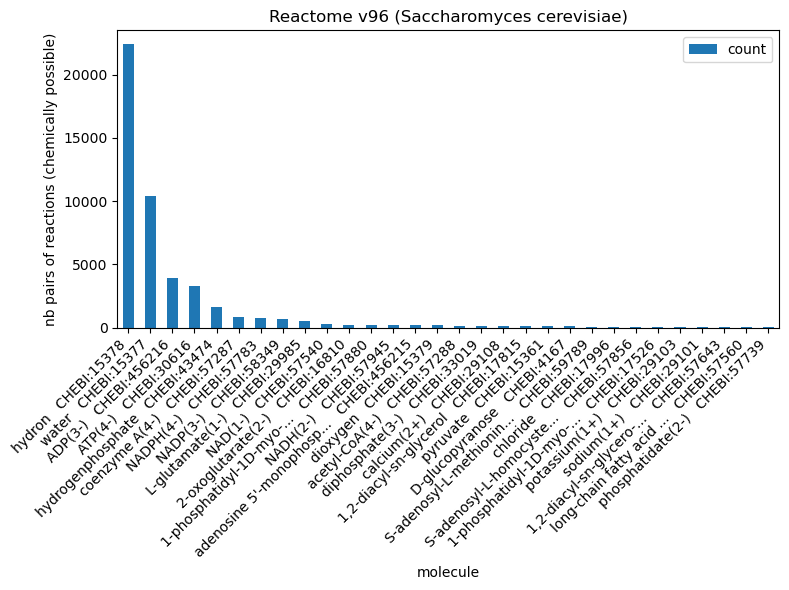

In [32]:
ax = dfMoleculeReactionPairsChemicallyPossible.head(30).plot.bar(x="molecule", y="count", ylabel="nb pairs of reactions (chemically possible)", title="Reactome v{} (Saccharomyces cerevisiae)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_sce_chebiMoleculesNbReactionPairs_chemicallyPossible.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

## 5.4 Biologically-relevant sequences of reactions

In [33]:
dfMoleculeReactionPairsBiologicallyRelevant = dfMoleculeLabel.join(dfReactionToMoleculeToReactionBiologicallyRelevant['chebiID'].value_counts().to_frame(), on = 'chebiID', how = 'inner').sort_values(by = 'count', ascending = False)
dfMoleculeReactionPairsBiologicallyRelevant.head()

,chebiID,moleculeChebiLabel,count
28,CHEBI:15378,hydron,30
166,CHEBI:57880,1-phosphatidyl-1D-myo-inositol(1-),29
112,CHEBI:57643,"1,2-diacyl-sn-glycero-3-phosphocholine",15
583,CHEBI:57613,phosphatidylethanolamine zwitterion,12
348,CHEBI:17526,1-phosphatidyl-1D-myo-inositol 4-phosphate,11


In [34]:
res = []
for i, row in dfMoleculeReactionPairsBiologicallyRelevant.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMoleculeReactionPairsBiologicallyRelevant['molecule'] = res

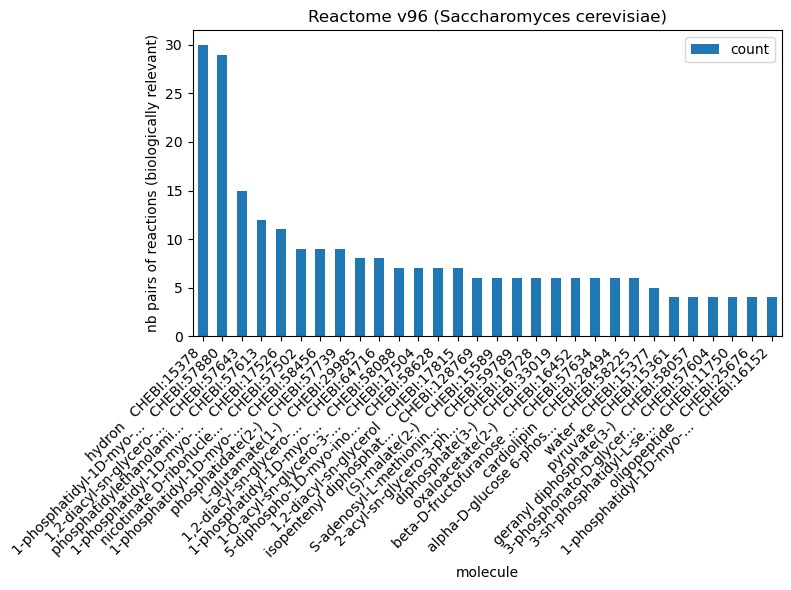

In [35]:
ax = dfMoleculeReactionPairsBiologicallyRelevant.head(30).plot.bar(x="molecule", y="count", ylabel="nb pairs of reactions (biologically relevant)", title="Reactome v{} (Saccharomyces cerevisiae)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_sce_chebiMoleculesNbReactionPairs_biologicallyRelevant.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

## 5.5 Over-represented molecules in chemically-possible sequences of reactions

In [36]:
nbReactionPairsChemicallyPossible = len(dfReactionToMoleculeToReactionChemicallyPossible[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct chemically-possible pairs of reactions: {}".format(nbReactionPairsChemicallyPossible))

Nb distinct chemically-possible pairs of reactions: 47595


In [37]:
nbReactionPairsBiologicallyRelevant = len(dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct biologically-relevant pairs of reactions: {}".format(nbReactionPairsBiologicallyRelevant))

Nb distinct biologically-relevant pairs of reactions: 484


In [38]:
moleculesChemicallyPossible = set(dfMoleculeReactionPairsChemicallyPossible['chebiID'])
moleculesBiologicallyRelevant = set(dfMoleculeReactionPairsBiologicallyRelevant['chebiID'])
print("Nb distinct ChEBI identifiers chemically-possible: {}".format(len(moleculesChemicallyPossible)))
print("Nb distinct ChEBI identifiers biologically-relevant: {}".format(len(moleculesBiologicallyRelevant)))
print("Nb distinct ChEBI identifiers common: {}".format(len(moleculesChemicallyPossible.intersection(moleculesBiologicallyRelevant))))

Nb distinct ChEBI identifiers chemically-possible: 311
Nb distinct ChEBI identifiers biologically-relevant: 214
Nb distinct ChEBI identifiers common: 214


In [39]:
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculeReactionPairsChemicallyPossible[['chebiID', 'count']].copy().rename(columns={'count': 'countChemicallyPossible'})
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculesChemicallyPossibleBiologicallyRelevant.join(dfMoleculeReactionPairsBiologicallyRelevant[['chebiID', 'count']].set_index('chebiID'), on='chebiID', how='inner').rename(columns={'count': 'countBiologicallyRelevant'})
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculesChemicallyPossibleBiologicallyRelevant.join(dfMoleculeLabel.set_index('chebiID'), on='chebiID', how='inner')

dfMoleculesChemicallyPossibleBiologicallyRelevant['freqChemicallyPossible'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible'] / nbReactionPairsChemicallyPossible
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqBiologicallyRelevant'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant'] / nbReactionPairsBiologicallyRelevant

dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant
28,CHEBI:15378,22386,30,hydron,0.470344,0.061983
178,CHEBI:15377,10413,5,water,0.218783,0.010331
595,CHEBI:456216,3920,2,ADP(3-),0.082362,0.004132
48,CHEBI:57287,840,3,coenzyme A(4-),0.017649,0.006198
685,CHEBI:57783,767,2,NADPH(4-),0.016115,0.004132


In [40]:
dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundChemicallyPossible"] = stats.hypergeom.cdf(dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant']-1, nbReactionPairsChemicallyPossible, dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible'], nbReactionPairsBiologicallyRelevant)
dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueBackgroundChemicallyPossible"] = stats.false_discovery_control(dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundChemicallyPossible"]) # Benjamini-Hochberg


In [41]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueBackgroundChemicallyPossible'] <= 0.05]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible
28,CHEBI:15378,22386,30,hydron,0.470344,0.061983,5.801136e-90,1.241443e-87
178,CHEBI:15377,10413,5,water,0.218783,0.010331,9.512775e-46,1.017867e-43
595,CHEBI:456216,3920,2,ADP(3-),0.082362,0.004132,3.084177e-17,2.200046e-15
139,CHEBI:58349,720,1,NADP(3-),0.015128,0.002066,6.017285e-04,3.219247e-02


In [42]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.to_csv("results/reactome_version{}_sce_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)


In [43]:
from scipy.stats import fisher_exact

In [44]:
res = []
for r in dfMoleculesChemicallyPossibleBiologicallyRelevant.itertuples(index=False):
    res.append(fisher_exact([[r.countChemicallyPossible, nbReactionPairsChemicallyPossible], [r.countBiologicallyRelevant, nbReactionPairsBiologicallyRelevant]], alternative='greater').pvalue)
dfMoleculesChemicallyPossibleBiologicallyRelevant['pvalueFisher'] = res
dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueFisher"] = stats.false_discovery_control(dfMoleculesChemicallyPossibleBiologicallyRelevant["pvalueFisher"]) # Benjamini-Hochberg


In [45]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pvalueFisher,adjPvalueFisher
28,CHEBI:15378,22386,30,hydron,0.470344,0.061983,5.801136e-90,1.241443e-87,9.279438e-48,1.985800e-45
178,CHEBI:15377,10413,5,water,0.218783,0.010331,9.512775e-46,1.017867e-43,1.716848e-34,1.837027e-32
595,CHEBI:456216,3920,2,ADP(3-),0.082362,0.004132,3.084177e-17,2.200046e-15,1.962027e-14,1.399579e-12
48,CHEBI:57287,840,3,coenzyme A(4-),0.017649,0.006198,8.344227e-03,2.976108e-01,3.082332e-02,1.000000e+00
685,CHEBI:57783,767,2,NADPH(4-),0.016115,0.004132,3.327904e-03,1.424343e-01,1.703722e-02,7.291931e-01


In [46]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueFisher'] <= 0.05]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pvalueFisher,adjPvalueFisher
28,CHEBI:15378,22386,30,hydron,0.470344,0.061983,5.801136e-90,1.241443e-87,9.279438e-48,1.985800e-45
178,CHEBI:15377,10413,5,water,0.218783,0.010331,9.512775e-46,1.017867e-43,1.716848e-34,1.837027e-32
595,CHEBI:456216,3920,2,ADP(3-),0.082362,0.004132,3.084177e-17,2.200046e-15,1.962027e-14,1.399579e-12
